# Multilayer perceptron (MLP)

Till now we have implemented our character level language model using bigrams only where we predict the next character based on previous character only. Also we tried to use neural network based approach for this and achieved a similar loss. Lets see if we can improve the efficiency of our model more.

One way is to use more context (more previous characters) to predict to next character. Another way is to use deeper networks with more layers. We will try to implement both.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

### 1. Preparing dataset

We will use the same `names.txt` data that we used in our bigram language modeling. This time we will increase the context to 3 characters i.e. 3 characters will now be the input to our model.

In [2]:
words = open("data/names.txt").read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
chars = sorted(set(''.join(words + ['.'])))
vocab_size = len(chars)
ch_to_i = {ch: i for i, ch in enumerate(chars)}
i_to_ch = {i: ch for i, ch in enumerate(chars)}

print(f"{vocab_size=}")
print(f"{ch_to_i=}")
print(f"{i_to_ch=}")

vocab_size=27
ch_to_i={'.': 0, 'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26}
i_to_ch={0: '.', 1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z'}


In [4]:
block_size = 3 # context length (no. of characters used to predict next one)

X, y = [], []

for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in list(w) + ['.']:
        ix = ch_to_i[ch]
        X.append(context)
        y.append(ix)
        print(f"{''.join(i_to_ch[ch] for ch in context)} --> {ch}")
        context = context[1:] + [ix]

X = torch.tensor(X)
y = torch.tensor(y)

emma
... --> e
..e --> m
.em --> m
emm --> a
mma --> .
olivia
... --> o
..o --> l
.ol --> i
oli --> v
liv --> i
ivi --> a
via --> .
ava
... --> a
..a --> v
.av --> a
ava --> .
isabella
... --> i
..i --> s
.is --> a
isa --> b
sab --> e
abe --> l
bel --> l
ell --> a
lla --> .
sophia
... --> s
..s --> o
.so --> p
sop --> h
oph --> i
phi --> a
hia --> .


In [5]:
print(f"{X.shape=}, {X.dtype=}")
print(f"{y.shape=}, {y.dtype=}")

X.shape=torch.Size([32, 3]), X.dtype=torch.int64
y.shape=torch.Size([32]), y.dtype=torch.int64


### 2. Feature vectors (or Embeddings)

Previously in our bigram model, we used to directly feed in our input characters as context by representing them as a single number into our neural networks. But this doesn't allow the model to get much info from the context when making predictions. 

For example, given only the area of house, its very difficult to predict its price. Need more details.

Thus it seems intuitively better to have more numbers instead of just one when representing the input context. This will allow the model to look into more dimensions to get a better understanding of the input context and thus make more informed predictions.

For example, given the area of house age, no. of floors, city, parking, etc. it becomes easier to make a prediction for its price.

This [paper](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf) suggests something similar. It says that words can be represented as feature vectors (a list of numbers) which then can be used as input context to the model to produce the output. The feature vector represents different aspects of the word where each word is associated with a point in a vector space. The feature
vectors associated with each word can be learned as parameters, but they can also be initialized using prior knowledge of semantic features. 

When learned these feature vectors tend to organize themselves in a way that semantically similar words group together within the vector space thus have similar feature vectors.

For example, if we knew that dog and cat played similar roles (semantically and syntactically), and similarly for (the, a), (bedroom, room), (is, was), (running, walking), we could naturally generalize  
from&emsp;&emsp;&emsp;&emsp;&emsp;*The cat is walking in the bedroom*  
to&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;*A dog was running in a room*  
and likewise to *The cat is running in a room*  
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;*A dog is walking in a bedroom*  
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;*The dog was walking in the room*  
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;*...*  
and many other combinations. It will so generalize because “similar” words are expected to have a similar feature vector, and because the probability function is a smooth function of these feature values, a small change in the features will induce a small change in the
probability. Therefore, the presence of only one of the above sentences in the training data will increase the probability, not only of that sentence, but also of its combinatorial number of “neighbors” in sentence space (as represented by sequences of feature vectors).

Since these feature vectors embed the semantic characteristics of a word they are also called as **word embeddings**.

#### 2.1 Embedding intuition

Since we are working on a character level langauge model, our embeddings will of characters instead of words. Since we have `vocab_size` no. of characters, we want to represent them as feature vectors of n-dimensions. So basically each character will be represented as a list of n numbers. Initially these vectors are just random numbers but the model has to learn the semantic similarites between them so that semantically similar vectors are close to each other within the vector space.

One thing to consider here is that when input batch (B) with context length (C) is fed into the model, it first gets the corresponding embeddings. Since each embedding is of D dimension, the resultant input will have dimension as (B, C, D). But since the context is fed as a combined input to the hidden layer we have to reshape the input dimension as (B, C*D).

In [6]:
C = torch.randn((vocab_size, 2))
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [7]:
emb.view(emb.shape[0], -1).shape

torch.Size([32, 6])

### 3. Defining model

We will define our model architecture based on this [paper](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf). Only difference is that this paper takes words as input context whereas we are using characters as we are training a character-level model.

We are following the below architecture for our training. The network contains 3 layers:
1. Embedding layer of dimension 27 x 2 i.e. 2 vectors embeddings for each of the 27 characters (A-Z + .). This is basically a lookup table shared across the input characters. Each training example contains 3 characters of context. Each of these characters is embedded into 2 vectors creating a total input size of 3 x 2 = 6.
2. Hidden layer of dimension 6 x 100 with tanh activation i.e. 6 inputs for 100 neurons each.
3. Output layer of dimension 100 x 27 with softmax activation i.e. 100 inputs for 27 neurons each. The outputs represent the probabilities of each of the 27 characters (A-Z + .).

![Screenshot 2026-01-20 142556.png](<attachment:Screenshot 2026-01-20 142556.png>)

**Loss:** Negative log likelihood

**Training goal:** To increase the likelihood of the label (required character) by increasing its probability in the output layer for the given input characters.
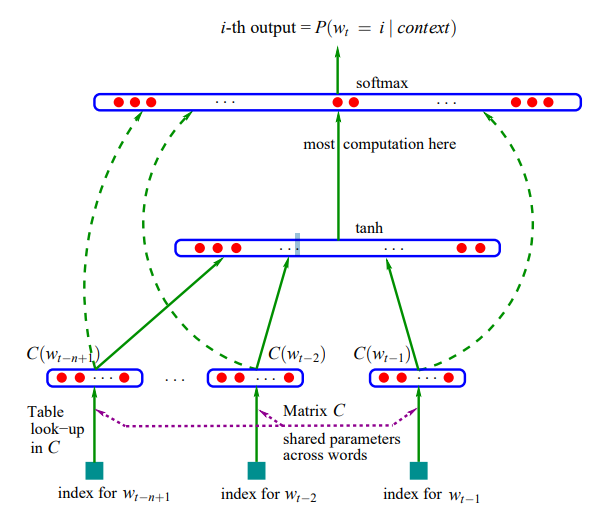

In [21]:
import random
random.seed(42)
random.shuffle(words)

block_size = 3 # context length (no. of characters used to predict next one)

def build_dataset(words, name):
    X, y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = ch_to_i[ch]
            X.append(context)
            y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    y = torch.tensor(y)
    print(f"X_{name}={X.shape}, y_{name}={y.shape}")
    return X, y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, ytr = build_dataset(words[:n1], 'train')
Xdev, ydev = build_dataset(words[n1:n2], 'dev')
Xte, yte = build_dataset(words[n2:], 'test')

X_train=torch.Size([182580, 3]), y_train=torch.Size([182580])
X_dev=torch.Size([22740, 3]), y_dev=torch.Size([22740])
X_test=torch.Size([22826, 3]), y_test=torch.Size([22826])


In [ ]:
torch.manual_seed(42)

class MLP(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()

        self.C = nn.Embedding(num_embeddings=vocab_size, embedding_dim=emb_dim)
        self.W1 = nn.Linear(emb_dim*block_size, 100)
        self.tanh = nn.Tanh()
        self.W2 = nn.Linear(100, vocab_size)

    def forward(self, x, targets=None):
        emb = self.C(x) # (B, 3, 2)
        x = emb.view(x.shape[0], -1) # (B, 6)
        x = self.W1(x) # (B, 100)
        x = self.tanh(x) # (B, 100)
        logits = self.W2(x) # (B, vocab_size)
        loss = None
        if targets != None:
            loss = F.cross_entropy(logits, targets)
        
        return logits, loss


In [11]:
model = MLP(vocab_size=vocab_size, emb_dim=2)
print(f"Total parameters = {sum(p.numel() for p in model.parameters())}")

optimizer = torch.optim.AdamW(model.parameters(), lr=0.01)

Total parameters = 3481


In [23]:
max_steps = 200000

for step in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], size=(32,))

    logits, loss = model(Xtr[ix], ytr[ix])
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if step % 100 == 0 or step == max_steps-1:
        print(f"step: {step}, loss: {loss.item():.4f}")

step: 0, loss: 2.8566
step: 100, loss: 2.5218
step: 200, loss: 2.7398
step: 300, loss: 2.0598
step: 400, loss: 2.0043
step: 500, loss: 2.6160
step: 600, loss: 2.4383
step: 700, loss: 2.3792
step: 800, loss: 2.3032
step: 900, loss: 2.4335
step: 1000, loss: 2.4142
step: 1100, loss: 2.2797
step: 1200, loss: 2.4825
step: 1300, loss: 2.6138
step: 1400, loss: 2.0560
step: 1500, loss: 2.4689
step: 1600, loss: 2.3770
step: 1700, loss: 2.3175
step: 1800, loss: 2.1701
step: 1900, loss: 2.6504
step: 2000, loss: 2.5842
step: 2100, loss: 2.2499
step: 2200, loss: 2.3452
step: 2300, loss: 2.1737
step: 2400, loss: 2.1683
step: 2500, loss: 2.2387
step: 2600, loss: 2.4352
step: 2700, loss: 2.0974
step: 2800, loss: 2.2450
step: 2900, loss: 2.3971
step: 3000, loss: 2.0933
step: 3100, loss: 2.4272
step: 3200, loss: 2.4594
step: 3300, loss: 2.2297
step: 3400, loss: 2.3350
step: 3500, loss: 2.3932
step: 3600, loss: 2.0615
step: 3700, loss: 2.3953
step: 3800, loss: 2.2881
step: 3900, loss: 2.7889
step: 4000, 

KeyboardInterrupt: 